# Windows Dataset Explorer -- Manual (upgraded)

Personal working notebook over `windows.parquet`. Upgraded from the first pass to:
- fix the between/within-person separation-ratio metric, which was previously
  dominated by degenerate near-empty features (sparsity, not real signal)
- restrict feature scans to actual behavioural columns (typing/tap/gesture/
  motion/coupling), not context/metadata columns that happen to be numeric
- add a `deviceModel`-based confound check, since `tap_radiusX`/`tap_radiusY`/
  `tap_force` turned out to be near-perfectly device-locked on iOS, not
  behavioural, despite ranking at the top of the old separation-ratio list
- correct the `feature_families` dict (`scroll_` isn't a real prefix -- scroll
  lives inside `gesture_`; `coupling_` was missing entirely, and is the
  largest family by column count)


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 60); pd.set_option('display.width', 220)
mpl.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.22,
                      'axes.titlesize': 11, 'axes.labelsize': 10, 'legend.fontsize': 9})

_CANDIDATES = ["../../data/processed/windows.parquet",
               "data/processed/windows.parquet",
               "/mnt/user-data/uploads/windows.parquet"]
_path = next((p for p in _CANDIDATES if Path(p).exists()), None)
if _path is None:
    raise FileNotFoundError(f"windows.parquet not found in any of {_CANDIDATES}")

df = pd.read_parquet(_path)
print(f"Loaded {_path}")
print(f"{len(df):,} windows x {len(df.columns):,} columns")
print(f"{df['participantId'].nunique()} participants, {df['sessionId'].nunique()} sessions")


Loaded ../../data/processed/windows.parquet
2,962 windows x 617 columns
17 participants, 81 sessions


## 1. Structural overview

In [2]:
print("Shape:", df.shape)
print("\nData types:")
display(df.dtypes.value_counts())
print("\nColumns:")
print(df.columns.tolist())


Shape: (2962, 617)

Data types:


float64    580
object      20
bool         6
boolean      6
int64        5
Name: count, dtype: int64


Columns:
['sessionId', 'participantId', 'deviceFamily', 'window_index', 'window_start_s', 'window_end_s', 'deviceModel', 'devicePlatform', 'appVersion', 'consentVersion', 'schemaVersion', 'identitySource', 'usableForSignalExtraction', 'completedNormally', 'sessionIndex', 'sessionDurationMs', 'ctxTimeOfDay', 'ctxFatigue', 'ctxFocusLevel', 'ctxEnvironmentNoise', 'ctxMovement', 'ctxPosture', 'ctxHandUse', 'ctxInputDevice', 'ctxCaffeine', 'ctxAlcohol', 'ctxPrivacy', 'taskIndex', 'taskType', 'activeArea', 'task_pass', 'task_start_s', 'task_end_s', 'typing_afforded', 'tapping_afforded', 'scrolling_afforded', 'typing_observed', 'tapping_observed', 'scrolling_observed', 'task_boundary_straddle', 'typing_straddle_conflict', 'tapping_straddle_conflict', 'scrolling_straddle_conflict', 'typing_keydown_count', 'typing_backspace_share', 'typing_autorepeat_share', 'typing_share_letter', 'typing_share_space', 'typing_share_backspace', 'typing_share_digit', 'typing_share_punct_or_symbol', 'typing_shar

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2962 entries, 0 to 2961
Columns: 617 entries, sessionId to motion_cross_axis_corr_slope
dtypes: bool(6), boolean(6), float64(580), int64(5), object(20)
memory usage: 13.7+ MB


In [4]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
sessionId,2962,81,403e8f08544c47b083f7dde8490cd145,131,NaN,NaN,NaN,NaN,NaN,NaN,NaN
participantId,2962,17,p95MPVX,575,NaN,NaN,NaN,NaN,NaN,NaN,NaN
deviceFamily,2962,2,mobile,2912,NaN,NaN,NaN,NaN,NaN,NaN,NaN
window_index,2962.0,NaN,NaN,NaN,24.907157,23.463952,0.0,9.0,19.0,32.0,130.0
window_start_s,2962.0,NaN,NaN,NaN,186.836244,175.98191,0.001,67.52125,142.5015,240.044,975.045
...,...,...,...,...,...,...,...,...,...,...,...
motion_cross_axis_corr_p95,2833.0,NaN,NaN,NaN,0.699742,0.295758,-0.804014,0.625671,0.804005,0.895902,0.99897
motion_cross_axis_corr_max,2833.0,NaN,NaN,NaN,0.748143,0.2668,-0.760207,0.696781,0.8413,0.915722,0.999047
motion_cross_axis_corr_n,2833.0,NaN,NaN,NaN,199.829156,59.118362,4.0,160.0,204.0,250.0,292.0
motion_cross_axis_corr_cv,2833.0,NaN,NaN,NaN,3.868714,73.791377,0.000124,0.248414,0.490845,1.145129,3824.450321


In [5]:
for col in df.columns:
    print(f"{col:50} unique={df[col].nunique(dropna=True):5} dtype={str(df[col].dtype):10}")


sessionId                                          unique=   81 dtype=object    
participantId                                      unique=   17 dtype=object    
deviceFamily                                       unique=    2 dtype=object    
window_index                                       unique=  131 dtype=int64     
window_start_s                                     unique= 1590 dtype=float64   
window_end_s                                       unique= 1590 dtype=float64   
deviceModel                                        unique=   10 dtype=object    
devicePlatform                                     unique=    3 dtype=object    
appVersion                                         unique=    1 dtype=object    
consentVersion                                     unique=    1 dtype=object    
schemaVersion                                      unique=    1 dtype=object    
identitySource                                     unique=    1 dtype=object    
usableForSignalExtraction   

## 2. Participant & session composition

In [6]:
user_counts = df["participantId"].value_counts()
display(user_counts)


participantId
p95MPVX    575
pH3S4X4    559
p3YDMHG    333
pG5G4MS    226
pNDG8LJ    201
pUNKH7L    200
pAFQRTM    131
p3M6E7Z    126
pA6XL23    122
pEZVKTS    101
pWS9VTN     86
pWJGKPK     81
pEAB9GS     78
pZMC82M     57
pCTJ44P     36
pG2C8BC     27
pCURDWC     23
Name: count, dtype: int64

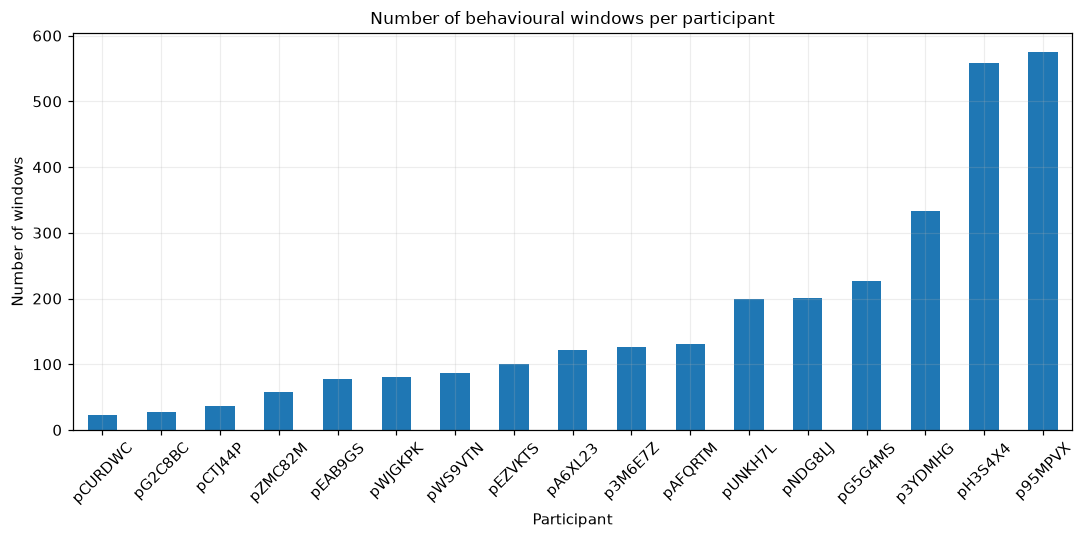

In [7]:
plt.figure(figsize=(10, 5))
user_counts.sort_values().plot(kind="bar")
plt.xlabel("Participant"); plt.ylabel("Number of windows")
plt.title("Number of behavioural windows per participant")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()


In [8]:
user_share = df["participantId"].value_counts(normalize=True).mul(100)
display(user_share)


participantId
p95MPVX    19.412559
pH3S4X4    18.872384
p3YDMHG    11.242404
pG5G4MS     7.629980
pNDG8LJ     6.785955
pUNKH7L     6.752194
pAFQRTM     4.422687
p3M6E7Z     4.253883
pA6XL23     4.118839
pEZVKTS     3.409858
pWS9VTN     2.903444
pWJGKPK     2.734639
pEAB9GS     2.633356
pZMC82M     1.924375
pCTJ44P     1.215395
pG2C8BC     0.911546
pCURDWC     0.776502
Name: proportion, dtype: float64

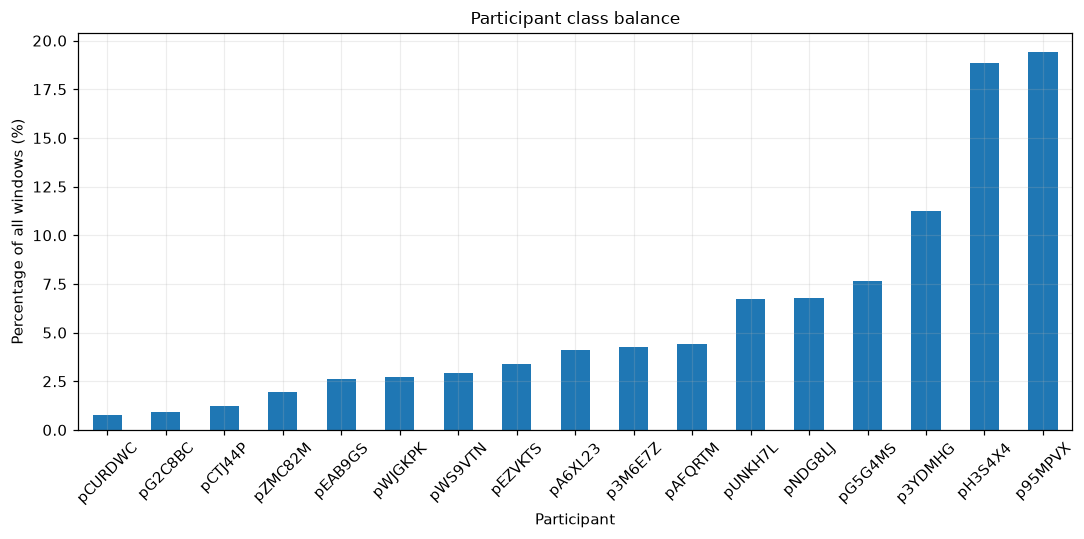

In [9]:
plt.figure(figsize=(10, 5))
user_share.sort_values().plot(kind="bar")
plt.xlabel("Participant"); plt.ylabel("Percentage of all windows (%)")
plt.title("Participant class balance")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()


In [10]:
sessions_per_user = df.groupby("participantId")["sessionId"].nunique().sort_values()
display(sessions_per_user)


participantId
p3M6E7Z     1
pWJGKPK     1
pG2C8BC     1
pCURDWC     1
pCTJ44P     1
pZMC82M     1
pWS9VTN     2
pAFQRTM     2
pEAB9GS     3
pUNKH7L     3
pA6XL23     4
pEZVKTS     4
pNDG8LJ     6
p3YDMHG    10
pH3S4X4    12
p95MPVX    14
pG5G4MS    15
Name: sessionId, dtype: int64

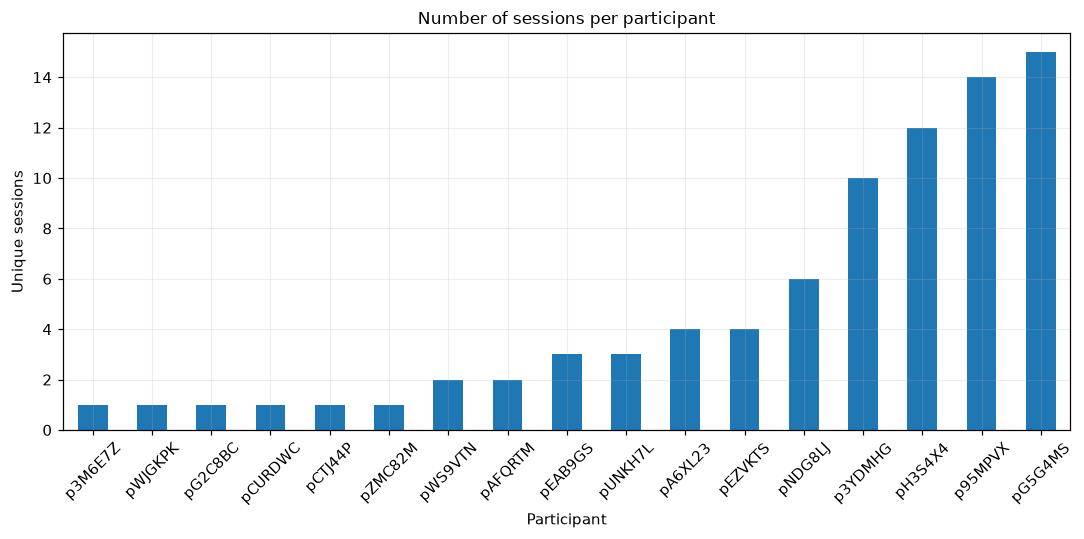

In [11]:
plt.figure(figsize=(10, 5))
sessions_per_user.plot(kind="bar")
plt.xlabel("Participant"); plt.ylabel("Unique sessions")
plt.title("Number of sessions per participant")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()


In [12]:
windows_per_session = (
    df.groupby(["participantId", "sessionId"]).size().rename("n_windows").reset_index()
)
display(windows_per_session)


,participantId,sessionId,n_windows
0,p3M6E7Z,d8efac44560c4faaba639beb6d1cbfca,126
1,p3YDMHG,084bc1a1666a44ca9cbf7cb96afc6faf,24
2,p3YDMHG,132afaaa28fc451587d0b238cd950bbe,29
3,p3YDMHG,181ec691b99545e591e4bc727fb6bd68,26
4,p3YDMHG,1c0986bb3ad8462292990cb030bb0db5,38
...,...,...,...
76,pUNKH7L,f7309697facd4ea6885b5b3f3d5e744f,23
77,pWJGKPK,7053d39b0267423298174f439f3ca5fc,81
78,pWS9VTN,68c94e6ce33a42538f81217fa7beb07f,33
79,pWS9VTN,96a3aebbf58b4b77a74be5c69f3b8b05,53


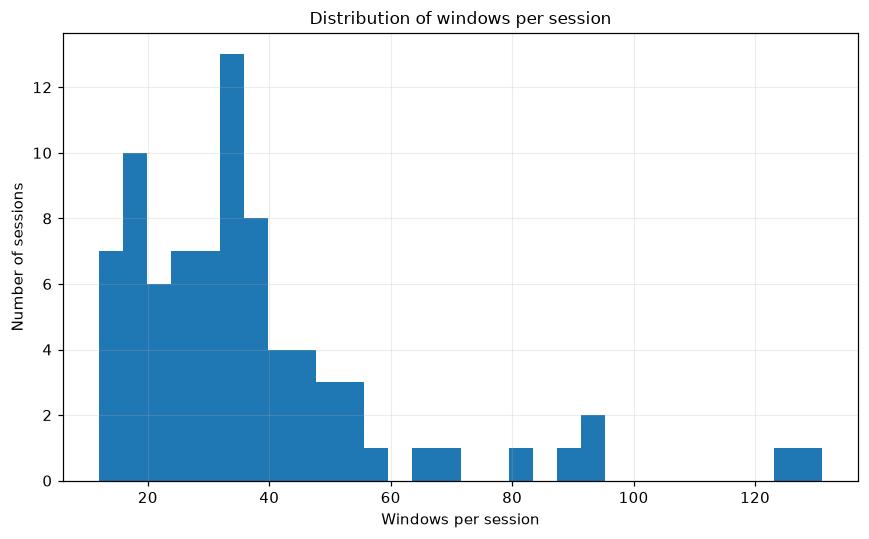

In [13]:
plt.figure(figsize=(8, 5))
plt.hist(windows_per_session["n_windows"], bins=30)
plt.xlabel("Windows per session"); plt.ylabel("Number of sessions")
plt.title("Distribution of windows per session")
plt.tight_layout(); plt.show()


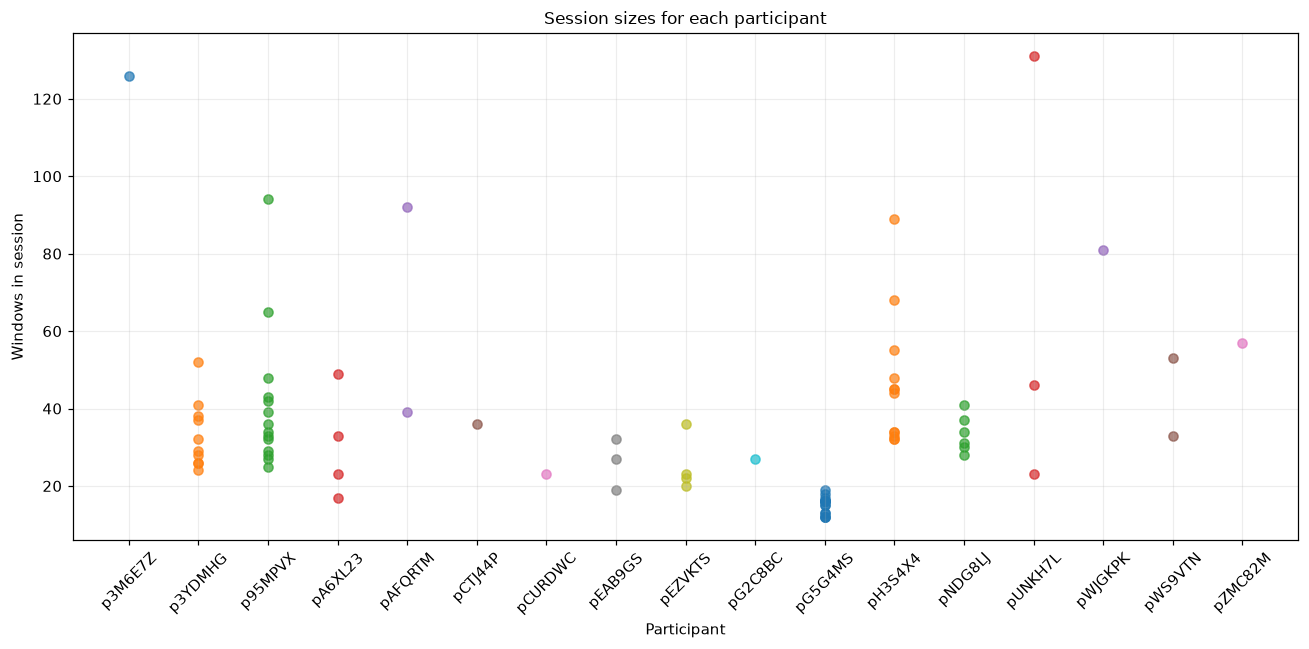

In [14]:
plt.figure(figsize=(12, 6))
for participant, group in windows_per_session.groupby("participantId"):
    plt.scatter([participant] * len(group), group["n_windows"], alpha=0.7)
plt.xlabel("Participant"); plt.ylabel("Windows in session")
plt.title("Session sizes for each participant")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()


## 3. Device composition

Now at `deviceModel` granularity (10 values) rather than just `deviceFamily`
(mobile/desktop). `deviceModel` is a per-participant constant (confirmed
separately) -- a participant never appears under more than one model -- which
means it behaves as a between-person confound axis, same as `deviceFamily` in
P1, just finer-grained. Several participants are the *sole* user of their
model; that's flagged explicitly below (`is_singleton_model`) because for
those people, "separable by device" and "separable by identity" are the same
test.

In [15]:
device_counts = df["deviceModel"].value_counts()
display(device_counts)


deviceModel
older_iphone                 942
iphone_13_13_mini            760
iphone_16_plus               685
iphone_17e                   159
iphone_16                    122
google_pixel_standard        101
iphone_13_pro_pro_max         86
iphone_15                     57
windows_laptop_with_mouse     27
macbook_trackpad              23
Name: count, dtype: int64

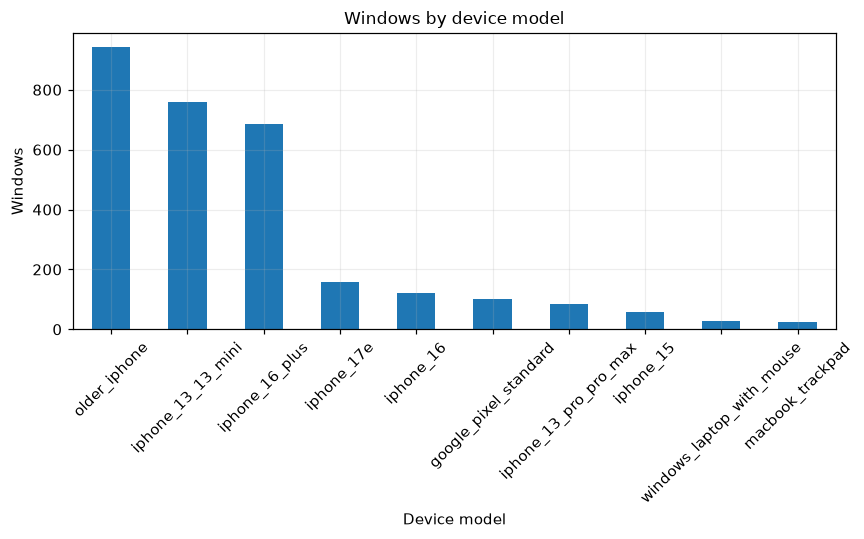

In [16]:
plt.figure(figsize=(8, 5))
device_counts.plot(kind="bar")
plt.xlabel("Device model"); plt.ylabel("Windows")
plt.title("Windows by device model")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()


In [17]:
user_device = pd.crosstab(df["participantId"], df["deviceModel"])
display(user_device)


deviceModel,google_pixel_standard,iphone_13_13_mini,iphone_13_pro_pro_max,iphone_15,iphone_16,iphone_16_plus,iphone_17e,macbook_trackpad,older_iphone,windows_laptop_with_mouse
participantId,,,,,,,,,,
p3M6E7Z,0,0,0,0,0,126,0,0,0,0
p3YDMHG,0,0,0,0,0,333,0,0,0,0
p95MPVX,0,0,0,0,0,0,0,0,575,0
pA6XL23,0,0,0,0,122,0,0,0,0,0
pAFQRTM,0,0,0,0,0,0,0,0,131,0
pCTJ44P,0,0,0,0,0,0,0,0,36,0
pCURDWC,0,0,0,0,0,0,0,23,0,0
pEAB9GS,0,0,0,0,0,0,78,0,0,0
pEZVKTS,101,0,0,0,0,0,0,0,0,0


In [18]:
participant_device = (
    df.groupby("participantId")
    .agg(
        deviceModel=("deviceModel", "first"),
        deviceFamily=("deviceFamily", "first"),
        n_sessions=("sessionId", "nunique"),
        n_windows=("deviceModel", "count"),
    )
)
participant_device["participants_sharing_model"] = participant_device["deviceModel"].map(
    df.drop_duplicates("participantId").groupby("deviceModel")["participantId"].nunique()
)
participant_device["is_singleton_model"] = participant_device["participants_sharing_model"] == 1
participant_device = participant_device.sort_values(["deviceModel", "participantId"])
display(participant_device)

print(f"\n{participant_device['is_singleton_model'].sum()} of {len(participant_device)} "
      f"participants are the sole user of their device model.")


,deviceModel,deviceFamily,n_sessions,n_windows,participants_sharing_model,is_singleton_model
participantId,,,,,,
pEZVKTS,google_pixel_standard,mobile,4,101,1,True
pH3S4X4,iphone_13_13_mini,mobile,12,559,2,False
pNDG8LJ,iphone_13_13_mini,mobile,6,201,2,False
pWS9VTN,iphone_13_pro_pro_max,mobile,2,86,1,True
pZMC82M,iphone_15,mobile,1,57,1,True
pA6XL23,iphone_16,mobile,4,122,1,True
p3M6E7Z,iphone_16_plus,mobile,1,126,3,False
p3YDMHG,iphone_16_plus,mobile,10,333,3,False
pG5G4MS,iphone_16_plus,mobile,15,226,3,False



6 of 17 participants are the sole user of their device model.


In [19]:
devices_per_user = df.groupby("participantId")["deviceModel"].nunique().sort_values()
display(devices_per_user)
assert (devices_per_user == 1).all(), "found a participant spanning >1 device model -- investigate"


participantId
p3M6E7Z    1
pWJGKPK    1
pUNKH7L    1
pNDG8LJ    1
pH3S4X4    1
pG5G4MS    1
pG2C8BC    1
pWS9VTN    1
pEZVKTS    1
pCURDWC    1
pCTJ44P    1
pAFQRTM    1
pA6XL23    1
p95MPVX    1
p3YDMHG    1
pEAB9GS    1
pZMC82M    1
Name: deviceModel, dtype: int64

## 4. Task composition

In [20]:
task_cols = [c for c in df.columns
             if any(w in c.lower() for w in ["task", "game", "activity", "mode"])]
print(task_cols)


['deviceModel', 'taskIndex', 'taskType', 'task_pass', 'task_start_s', 'task_end_s', 'task_boundary_straddle']


In [21]:
for col in task_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False).head(20))



--- deviceModel ---
deviceModel
older_iphone                 942
iphone_13_13_mini            760
iphone_16_plus               685
iphone_17e                   159
iphone_16                    122
google_pixel_standard        101
iphone_13_pro_pro_max         86
iphone_15                     57
windows_laptop_with_mouse     27
macbook_trackpad              23
Name: count, dtype: int64

--- taskIndex ---
taskIndex
3.0     291
14.0    250
13.0    227
5.0     190
16.0    177
22.0    157
7.0     135
9.0     128
2.0     111
6.0     110
17.0    103
18.0    103
1.0     102
10.0     99
20.0     96
11.0     86
8.0      84
24.0     84
NaN      81
21.0     77
Name: count, dtype: int64

--- taskType ---
taskType
typing_search       541
transaction_feed    367
guided_reply        311
insights_review     243
guided_note         238
pots_transfer       224
categorise          213
card_swipe          176
pot_drag            142
activity_filter     119
home_explore        111
tap_account         102
N

In [22]:
task_counts = df["taskType"].value_counts()
display(task_counts)


taskType
typing_search       541
transaction_feed    367
guided_reply        311
insights_review     243
guided_note         238
pots_transfer       224
categorise          213
card_swipe          176
pot_drag            142
activity_filter     119
home_explore        111
tap_account         102
swipe_approval       78
code                 15
finish                1
Name: count, dtype: int64

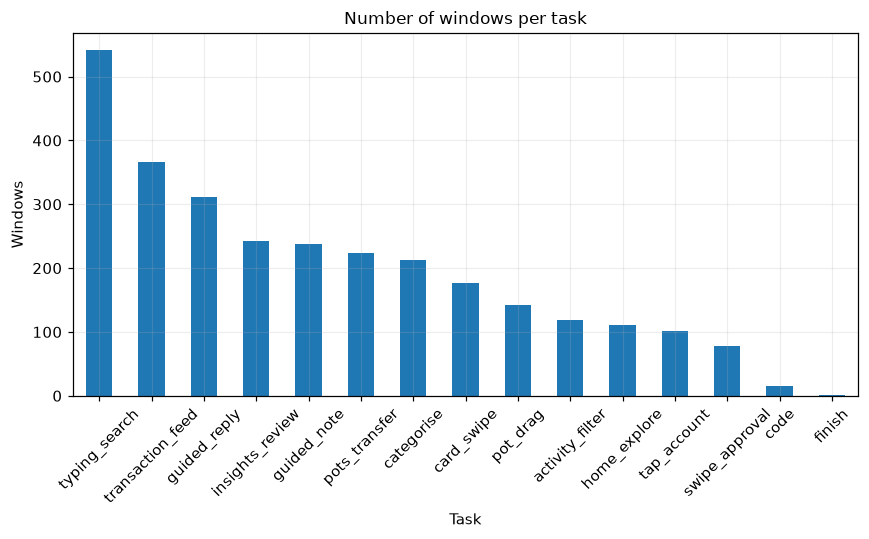

In [23]:
plt.figure(figsize=(8, 5))
task_counts.plot(kind="bar")
plt.xlabel("Task"); plt.ylabel("Windows")
plt.title("Number of windows per task")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()


In [24]:
user_task = pd.crosstab(df["participantId"], df["taskType"], normalize="index") * 100
display(user_task.round(1))


taskType,activity_filter,card_swipe,categorise,code,finish,guided_note,guided_reply,home_explore,insights_review,pot_drag,pots_transfer,swipe_approval,tap_account,transaction_feed,typing_search
participantId,,,,,,,,,,,,,,,
p3M6E7Z,7.2,4.8,4.8,0.8,0.0,13.6,17.6,3.2,2.4,4.0,4.8,1.6,4.8,8.8,21.6
p3YDMHG,3.7,7.7,7.1,0.9,0.0,9.0,14.2,3.1,5.6,4.6,7.7,3.1,4.0,11.5,17.6
p95MPVX,4.3,5.3,7.3,0.0,0.0,10.2,11.4,6.2,7.3,4.6,7.0,3.7,3.6,10.7,18.4
pA6XL23,4.2,8.5,9.3,1.7,0.0,5.9,9.3,3.4,5.1,8.5,7.6,1.7,2.5,16.9,15.3
pAFQRTM,3.9,4.7,5.4,0.8,0.8,7.0,24.8,1.6,5.4,7.0,7.8,0.8,3.1,6.2,20.9
pCTJ44P,0.0,5.7,8.6,2.9,0.0,0.0,25.7,8.6,0.0,5.7,5.7,5.7,2.9,8.6,20.0
pCURDWC,4.5,9.1,13.6,0.0,0.0,9.1,4.5,4.5,4.5,0.0,9.1,0.0,4.5,18.2,18.2
pEAB9GS,2.7,5.3,8.0,0.0,0.0,6.7,4.0,4.0,6.7,8.0,9.3,2.7,5.3,17.3,20.0
pEZVKTS,6.2,7.2,8.2,0.0,0.0,7.2,5.2,3.1,4.1,4.1,9.3,2.1,4.1,19.6,19.6


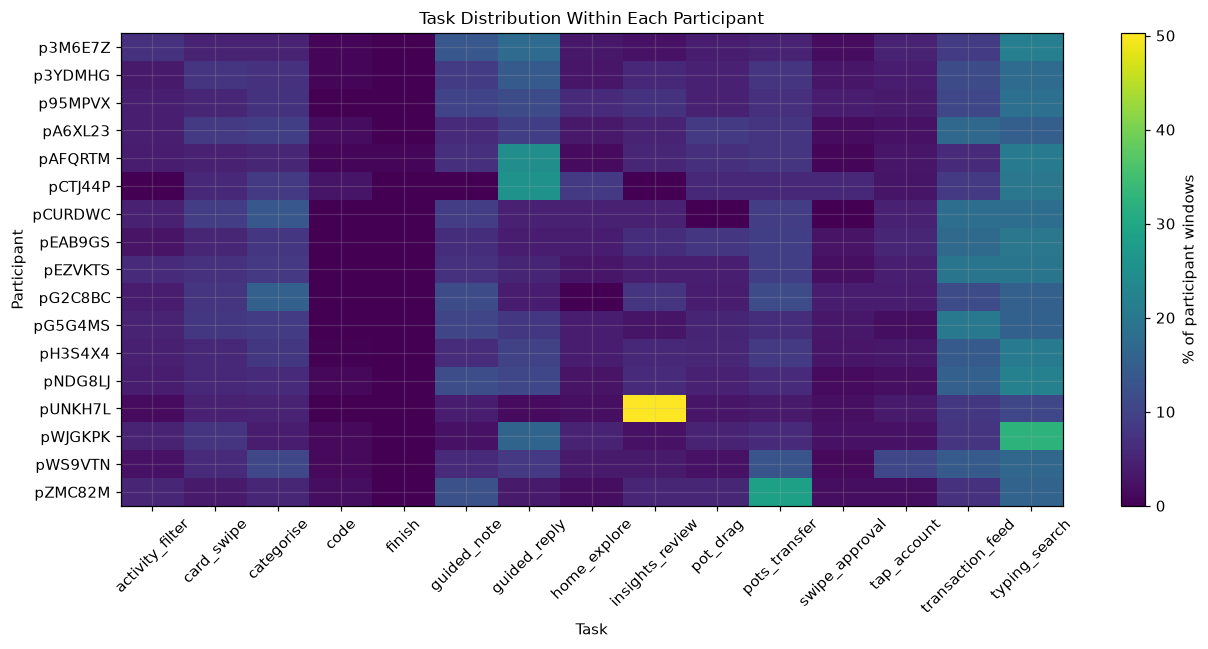

In [25]:
plt.figure(figsize=(12, 6))
plt.imshow(user_task, aspect="auto")
plt.colorbar(label="% of participant windows")
plt.xticks(range(len(user_task.columns)), user_task.columns, rotation=45)
plt.yticks(range(len(user_task.index)), user_task.index)
plt.xlabel("Task"); plt.ylabel("Participant")
plt.title("Task Distribution Within Each Participant")
plt.tight_layout(); plt.show()


## 5. Feature family inventory

Corrected from the first pass: `scroll_` was never a real column prefix
(scroll behaviour is folded into `gesture_share_scroll_fling` /
`gesture_share_scroll_drag` etc. -- scroll is a *kind* of gesture, not a
separate motor channel), and `coupling_` (tap/keystroke/gesture x
accelerometer/orientation cross-signal features) was missing even though
it's the single largest family by column count.

In [26]:
feature_families = {
    "typing":   [c for c in df.columns if c.startswith("typing_")],
    "tap":      [c for c in df.columns if c.startswith("tap_")],
    "gesture":  [c for c in df.columns if c.startswith("gesture_")],
    "coupling": [c for c in df.columns if c.startswith("coupling_")],
    "motion":   [c for c in df.columns if c.startswith("motion_")],
}
for family, cols in feature_families.items():
    print(f"{family:10}: {len(cols)} features")

FEATURE_COLS = sorted(c for cols in feature_families.values() for c in cols)
print(f"\n{len(FEATURE_COLS)} total behavioural feature columns")

CONTEXT_COLS = [
    "deviceModel", "devicePlatform", "appVersion", "consentVersion", "schemaVersion",
    "identitySource", "usableForSignalExtraction", "completedNormally",
    "sessionIndex", "sessionDurationMs",
    "ctxTimeOfDay", "ctxFatigue", "ctxFocusLevel", "ctxEnvironmentNoise",
    "ctxMovement", "ctxPosture", "ctxHandUse", "ctxInputDevice",
    "ctxCaffeine", "ctxAlcohol", "ctxPrivacy",
]
CONTEXT_COLS = [c for c in CONTEXT_COLS if c in df.columns]
print(f"{len(CONTEXT_COLS)} session-context columns present (not behavioural -- excluded from feature scans below)")


typing    : 184 features
tap       : 59 features
gesture   : 105 features
coupling  : 198 features
motion    : 31 features

577 total behavioural feature columns
21 session-context columns present (not behavioural -- excluded from feature scans below)


## 6. Missingness

In [27]:
family_missingness = {}
for family, cols in feature_families.items():
    if len(cols) > 0:
        family_missingness[family] = df[cols].isna().mean().mean() * 100
family_missingness = pd.Series(family_missingness).sort_values()
display(family_missingness)


tap         12.155094
motion      19.435429
gesture     48.405518
coupling    50.737115
typing      93.796054
dtype: float64

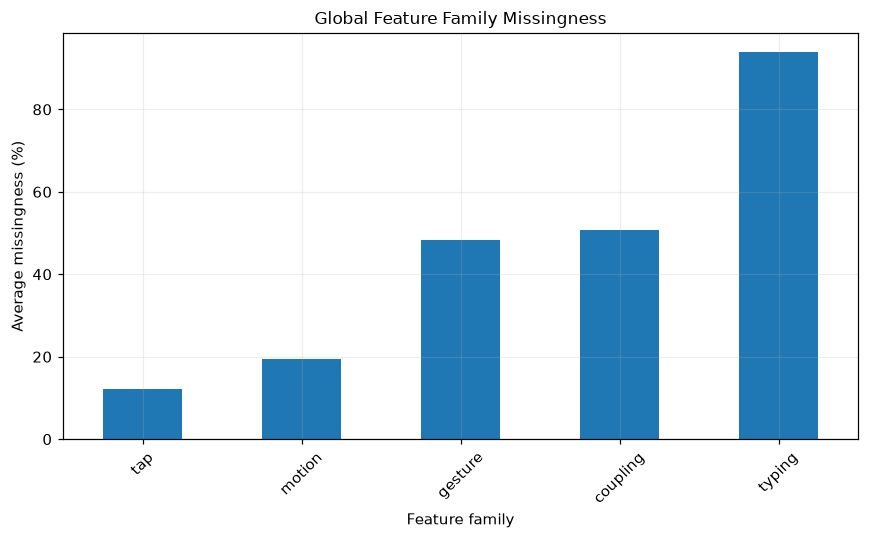

In [28]:
plt.figure(figsize=(8, 5))
family_missingness.plot(kind="bar")
plt.ylabel("Average missingness (%)"); plt.xlabel("Feature family")
plt.title("Global Feature Family Missingness")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()


In [29]:
typing_cols = feature_families["typing"]
typing_missing_by_task = (
    df.groupby("taskType")[typing_cols].apply(lambda x: x.isna().mean().mean() * 100).sort_values()
)
display(typing_missing_by_task)


taskType
guided_reply        74.592828
typing_search       89.233907
guided_note         94.425923
pots_transfer       96.962345
activity_filter     98.369565
card_swipe          98.369565
categorise          98.369565
code                98.369565
finish              98.369565
home_explore        98.369565
insights_review     98.369565
pot_drag            98.369565
swipe_approval      98.369565
tap_account         98.369565
transaction_feed    98.369565
dtype: float64

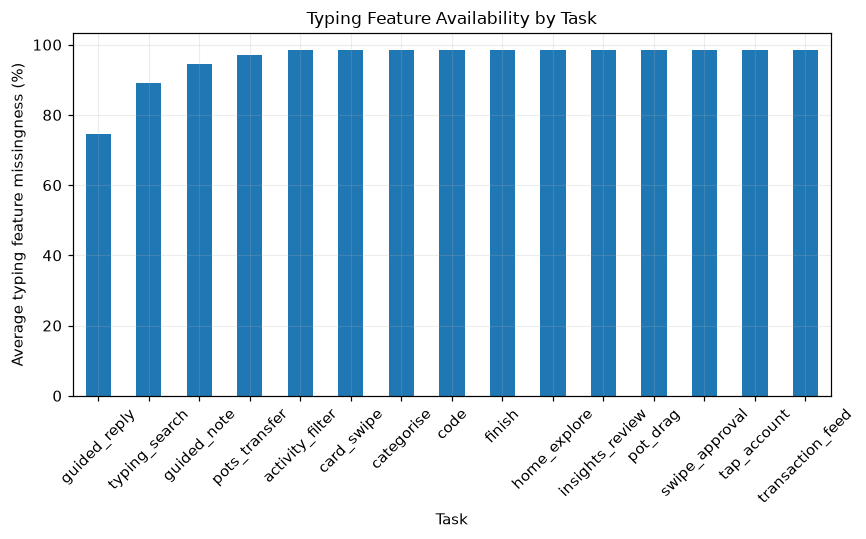

In [30]:
plt.figure(figsize=(8, 5))
typing_missing_by_task.plot(kind="bar")
plt.xlabel("Task"); plt.ylabel("Average typing feature missingness (%)")
plt.title("Typing Feature Availability by Task")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()


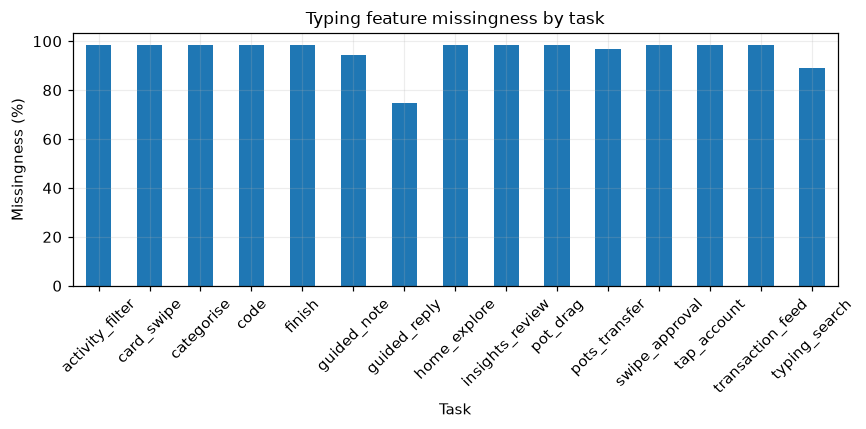

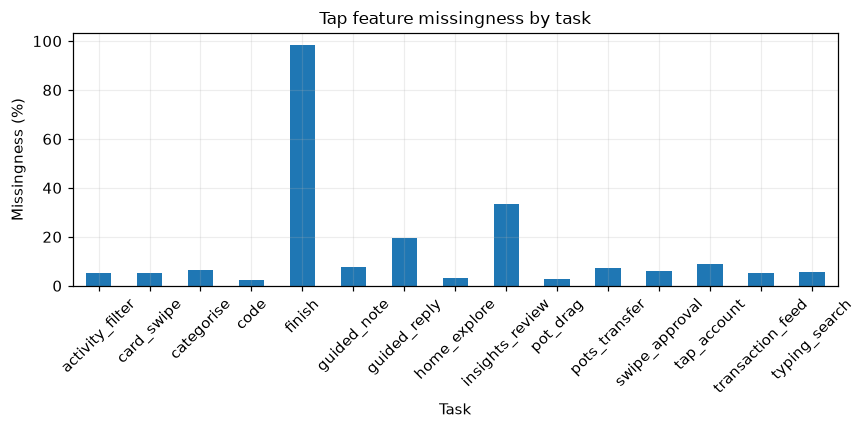

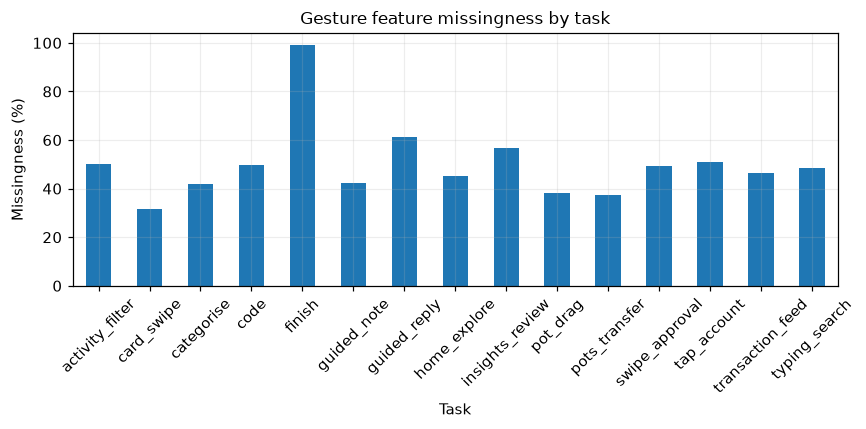

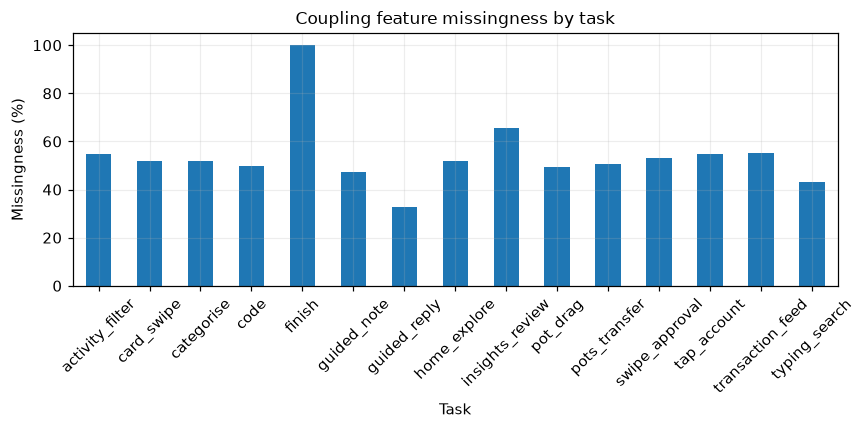

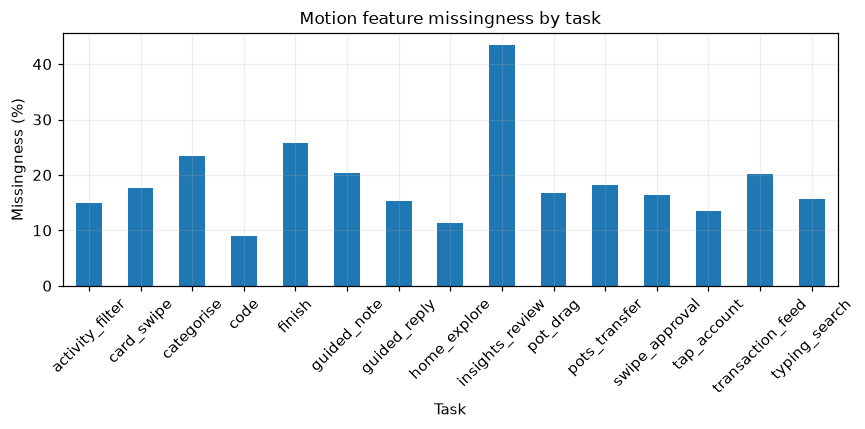

In [31]:
for family, cols in feature_families.items():
    if len(cols) == 0:
        continue
    missing_by_task = df.groupby("taskType")[cols].apply(lambda x: x.isna().mean().mean() * 100)
    plt.figure(figsize=(8, 4))
    missing_by_task.plot(kind="bar")
    plt.title(f"{family.capitalize()} feature missingness by task")
    plt.xlabel("Task"); plt.ylabel("Missingness (%)")
    plt.xticks(rotation=45); plt.tight_layout(); plt.show()


In [32]:
family_activity = pd.DataFrame(index=df.index)
for family, cols in feature_families.items():
    if len(cols) == 0:
        continue
    family_activity[family] = df[cols].notna().any(axis=1)

df["n_active_modalities"] = family_activity.sum(axis=1)
display(df["n_active_modalities"].value_counts().sort_index())


n_active_modalities
1       2
2      79
3     127
4      31
5    2723
Name: count, dtype: int64

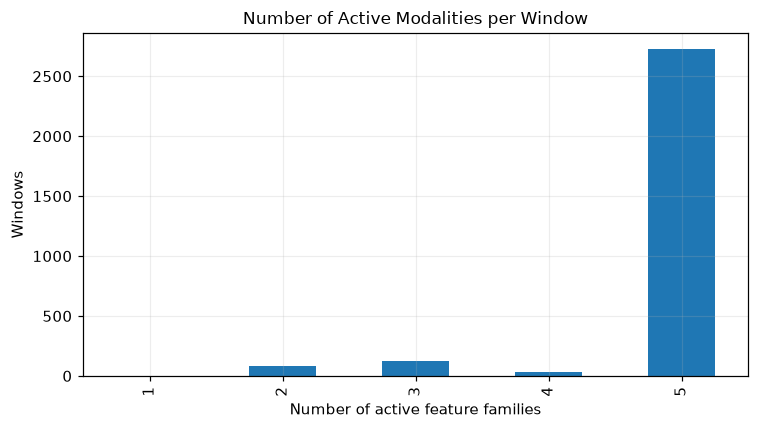

In [33]:
plt.figure(figsize=(7, 4))
df["n_active_modalities"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Number of active feature families"); plt.ylabel("Windows")
plt.title("Number of Active Modalities per Window")
plt.tight_layout(); plt.show()


## 7. Column diagnostics -- constant, near-constant, full spread

In [34]:
feature_variance = df[FEATURE_COLS].var().sort_values()
display(feature_variance.head(20))


typing_transition_space_space_ms_n              0.0
typing_transition_space_backspace_ms_n          0.0
coupling_tap_accel_z_share_slope            0.00043
tap_y_slope                                0.000571
gesture_stroke_y0_slope                    0.000813
coupling_key_accel_z_share_std             0.000818
tap_x_slope                                0.001108
motion_active_accel_mag_slope              0.001112
tap_coverage                               0.001127
coupling_tap_accel_z_share_std             0.001319
gesture_stroke_x0_slope                    0.001929
motion_cross_axis_corr_slope               0.002323
coupling_key_accel_z_share_iqr             0.002598
coupling_gesture_mid_phase_energy_slope     0.00261
coupling_tap_accel_z_share_iqr             0.003118
tap_y_std                                  0.003238
gesture_scroll_fling_coast_frac_slope      0.003807
motion_idle_tremor_power                    0.00389
gesture_share_long_press                   0.004029
coupling_key

In [35]:
display(feature_variance[feature_variance.notna()].tail(20))


gesture_hold_long_press_ms_median       2187060.828934
gesture_hold_scroll_fling_ms_median      2269867.61487
gesture_hold_scroll_fling_ms_mean       2293680.374329
gesture_hold_ms_median                   2399408.55137
gesture_hold_ms_mean                    2431876.591779
tap_hold_ms_max                          2658356.00096
gesture_hold_scroll_fling_ms_p95        2773872.752255
gesture_hold_long_press_ms_max          3087103.056095
gesture_hold_drag_swipe_ms_mean         3299888.054817
gesture_hold_drag_swipe_ms_median       3376524.822378
gesture_hold_scroll_fling_ms_max        3542837.392318
gesture_hold_drag_swipe_ms_max           4169554.28991
gesture_hold_long_press_ms_p95          4591015.719608
gesture_hold_ms_p95                     5098824.302437
gesture_hold_drag_swipe_ms_p95           5222658.85197
gesture_hold_ms_max                     5932960.967313
gesture_hold_scroll_drag_ms_mean        6293860.801075
gesture_hold_scroll_drag_ms_median      6320951.178789
gesture_ho

In [36]:
n_unique = df[FEATURE_COLS].nunique(dropna=True)
constant_cols = n_unique[n_unique <= 1].index.tolist()
print("Number of constant behavioural features:", len(constant_cols))
print(constant_cols)


Number of constant behavioural features: 25
['typing_backspace_run_length_slope', 'typing_dwell_punct_or_symbol_ms_slope', 'typing_transition_backspace_letter_ms_slope', 'typing_transition_backspace_space_ms_cv', 'typing_transition_backspace_space_ms_iqr', 'typing_transition_backspace_space_ms_max', 'typing_transition_backspace_space_ms_mean', 'typing_transition_backspace_space_ms_median', 'typing_transition_backspace_space_ms_n', 'typing_transition_backspace_space_ms_p95', 'typing_transition_backspace_space_ms_slope', 'typing_transition_backspace_space_ms_std', 'typing_transition_letter_backspace_ms_slope', 'typing_transition_space_backspace_ms_cv', 'typing_transition_space_backspace_ms_iqr', 'typing_transition_space_backspace_ms_n', 'typing_transition_space_backspace_ms_p95', 'typing_transition_space_backspace_ms_slope', 'typing_transition_space_backspace_ms_std', 'typing_transition_space_space_ms_cv', 'typing_transition_space_space_ms_iqr', 'typing_transition_space_space_ms_n', 'typ

In [37]:
near_constant = n_unique[n_unique <= 15].sort_values()
display(near_constant)


typing_transition_space_space_ms_std            0
typing_transition_space_space_ms_slope          0
typing_transition_backspace_letter_ms_slope     0
typing_transition_backspace_space_ms_cv         0
typing_transition_backspace_space_ms_iqr        0
                                               ..
typing_backspace_run_length_mean               14
typing_backspace_run_length_median             14
tap_coverage                                   15
typing_dwell_digit_ms_median                   15
tap_cells_touched                              15
Length: 85, dtype: int64

In [38]:
display(n_unique.sort_values())


typing_transition_space_space_ms_std              0
typing_transition_backspace_letter_ms_slope       0
typing_transition_backspace_space_ms_cv           0
typing_transition_backspace_space_ms_iqr          0
typing_transition_backspace_space_ms_max          0
                                               ... 
motion_cross_axis_corr_std                     2832
motion_cross_axis_corr_mean                    2832
motion_cross_axis_corr_iqr                     2832
motion_cross_axis_corr_cv                      2832
motion_cross_axis_corr_slope                   2833
Length: 577, dtype: int64

## 8. Between/within-person separation ratio -- FIXED

The first pass scanned every numeric column with no minimum-coverage filter.
For a near-empty column, `within_user_std` can be computed from 1-2 non-null
observations per participant, which is numerically near-zero and inflates
`separation_ratio` to absurd values (the previous run's #1 feature had a
ratio of ~4x10^14, purely a sparsity artifact, not a real effect).

Fixed version:
- restricted to `FEATURE_COLS` only (context/metadata excluded -- those aren't
  candidate model inputs and shouldn't compete in this ranking)
- a participant only counts if they have at least `MIN_COUNT_PER_PARTICIPANT`
  non-null windows for that feature (their std needs enough points to mean
  something)
- a feature only gets ranked if at least `MIN_PARTICIPANTS_WITH_DATA`
  participants clear that bar (otherwise the ranking is off a handful of
  people, not the cohort)


In [39]:
MIN_PARTICIPANTS_WITH_DATA = 8
MIN_COUNT_PER_PARTICIPANT = 10

rows = []
for feature in FEATURE_COLS:
    grouped = df.groupby("participantId")[feature].agg(["mean", "std", "count"])
    well_supported = grouped[grouped["count"] >= MIN_COUNT_PER_PARTICIPANT]
    if len(well_supported) < MIN_PARTICIPANTS_WITH_DATA:
        continue
    between = well_supported["mean"].std()
    within = well_supported["std"].mean()
    if pd.notna(between) and pd.notna(within) and within > 0:
        rows.append({
            "feature": feature,
            "n_participants_used": len(well_supported),
            "between_user_std": between,
            "within_user_std": within,
            "separation_ratio": between / within,
        })

separation_df = pd.DataFrame(rows).sort_values("separation_ratio", ascending=False)
print(f"{len(separation_df)} of {len(FEATURE_COLS)} behavioural features passed the "
      f"min-count/min-participant filter (>= {MIN_COUNT_PER_PARTICIPANT} windows/participant, "
      f">= {MIN_PARTICIPANTS_WITH_DATA} participants)")
display(separation_df.head(30))


410 of 577 behavioural features passed the min-count/min-participant filter (>= 10 windows/participant, >= 8 participants)


,feature,n_participants_used,between_user_std,within_user_std,separation_ratio
355,tap_radiusY_mean,15,20.337605,0.800399,25.409346
356,tap_radiusY_median,15,20.077282,1.039676,19.311104
358,tap_radiusY_p95,15,24.919437,1.568976,15.882607
354,tap_radiusY_max,15,26.023043,2.443051,10.651861
347,tap_radiusX_mean,15,14.922804,3.084550,4.837920
360,tap_radiusY_std,15,3.370309,0.715343,4.711458
350,tap_radiusX_p95,15,19.263163,4.477483,4.302230
329,tap_force_mean,15,9.791054,2.289227,4.277013
353,tap_radiusY_iqr,15,4.350323,1.045185,4.162253
346,tap_radiusX_max,15,19.782540,4.853490,4.075942


In [40]:
def get_family(feature):
    for family in feature_families:
        if feature.startswith(f"{family}_"):
            return family
    return "other"

separation_df["family"] = separation_df["feature"].apply(get_family)

family_separation = separation_df.groupby("family")["separation_ratio"].median().sort_values(ascending=False)
display(family_separation)


family
tap         0.781590
gesture     0.647106
motion      0.455145
typing      0.440405
coupling    0.399314
Name: separation_ratio, dtype: float64

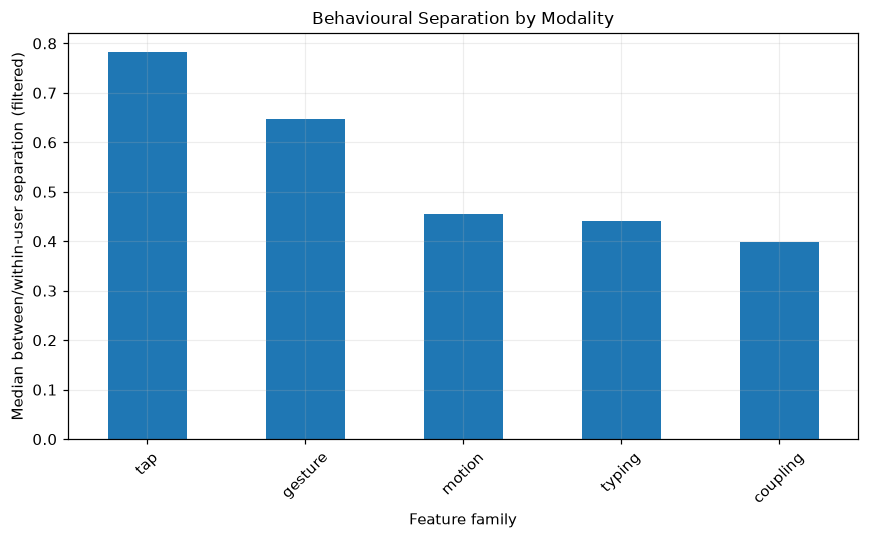

In [41]:
plt.figure(figsize=(8, 5))
family_separation.plot(kind="bar")
plt.xlabel("Feature family"); plt.ylabel("Median between/within-user separation (filtered)")
plt.title("Behavioural Separation by Modality")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()


## 9. Device-confound check

The top of the filtered separation-ratio list above is dominated by
`tap_radiusX`/`tap_radiusY`/`tap_force`. Before treating that as a genuine
behavioural finding, check whether it's actually a `deviceModel` fingerprint
-- touch-contact-area and pressure are exactly the kind of measurement a
touchscreen's hardware/API determines, not the person using it.

In [42]:
for feat in ["tap_radiusY_mean", "tap_radiusX_mean", "tap_force_mean"]:
    print(f"=== {feat} by deviceModel ===")
    display(df.groupby("deviceModel")[feat].agg(["mean", "std", "count"]).sort_values("mean"))
    print()


=== tap_radiusY_mean by deviceModel ===


,mean,std,count
deviceModel,,,
iphone_13_13_mini,0.000000,0.000000,729
iphone_13_pro_pro_max,0.000000,0.000000,84
iphone_15,0.000000,0.000000,49
iphone_16,0.000000,0.000000,118
iphone_16_plus,0.000000,0.000000,644
iphone_17e,0.000000,0.000000,155
older_iphone,5.343320,10.934210,834
google_pixel_standard,73.664169,5.790825,97
macbook_trackpad,NaN,NaN,0



=== tap_radiusX_mean by deviceModel ===


,mean,std,count
deviceModel,,,
iphone_13_13_mini,12.593208,0.140736,729
iphone_13_pro_pro_max,13.119928,2.519585,84
older_iphone,16.253068,6.191578,834
iphone_17e,22.045657,8.223896,155
iphone_16,22.383855,3.483151,118
iphone_16_plus,24.760118,3.365316,644
iphone_15,26.525876,2.308632,49
google_pixel_standard,73.734878,5.760963,97
macbook_trackpad,NaN,NaN,0



=== tap_force_mean by deviceModel ===


,mean,std,count
deviceModel,,,
google_pixel_standard,0.522588,0.046280,97
older_iphone,10.909748,5.958793,834
iphone_13_13_mini,12.593208,0.140736,729
iphone_13_pro_pro_max,13.119928,2.519585,84
iphone_17e,22.045657,8.223896,155
iphone_16,22.383855,3.483151,118
iphone_16_plus,24.760118,3.365316,644
iphone_15,26.525876,2.308632,49
macbook_trackpad,NaN,NaN,0


In [43]:
# row-level check: is tap_radiusX_mean == tap_force_mean exactly (not just
# coincidentally close per-device-mean)?
mobile = df[df["deviceFamily"] == "mobile"].dropna(subset=["tap_radiusX_mean", "tap_force_mean"])
identical = (mobile["tap_radiusX_mean"] == mobile["tap_force_mean"]).mean()
print(f"tap_radiusX_mean == tap_force_mean exactly, row-level: {identical:.1%} of {len(mobile):,} mobile rows")

iphone_rows = df[df["deviceModel"].str.contains("iphone_1[3-7]", na=False, regex=True)]
zero_radiusY = (iphone_rows["tap_radiusY_mean"] == 0).mean()
print(f"tap_radiusY_mean == 0 for newer iPhone models: {zero_radiusY:.1%} of {len(iphone_rows):,} rows")

for model in df["deviceModel"].dropna().unique():
    sub = df[df["deviceModel"] == model].dropna(subset=["tap_radiusX_mean", "tap_force_mean"])
    if len(sub) == 0:
        continue
    ident = (sub["tap_radiusX_mean"] == sub["tap_force_mean"]).mean()
    print(f"  {model:28s}: radiusX==force exactly in {ident:5.1%} of {len(sub):,} rows")


tap_radiusX_mean == tap_force_mean exactly, row-level: 90.4% of 2,710 mobile rows
tap_radiusY_mean == 0 for newer iPhone models: 95.2% of 1,869 rows
  iphone_17e                  : radiusX==force exactly in 100.0% of 155 rows


  iphone_16_plus              : radiusX==force exactly in 100.0% of 644 rows
  older_iphone                : radiusX==force exactly in 80.3% of 834 rows
  google_pixel_standard       : radiusX==force exactly in  0.0% of 97 rows
  iphone_16                   : radiusX==force exactly in 100.0% of 118 rows
  iphone_13_pro_pro_max       : radiusX==force exactly in 100.0% of 84 rows
  iphone_13_13_mini           : radiusX==force exactly in 100.0% of 729 rows
  iphone_15                   : radiusX==force exactly in 100.0% of 49 rows


In [44]:
print("CONCLUSION: tap_radiusX / tap_radiusY / tap_force behave as a deviceModel")
print("fingerprint on iOS (near-constant within model, sharply different across models,")
print("and radiusX/force are literally identical values on most iPhones -- almost")
print("certainly an unsupported browser API falling back to the same proxy value).")
print()
print("This is the same 'structural, not offset' pattern as P1 Section 6's device-regime")
print("finding, and it explains why these three features topped the separation-ratio")
print("ranking above: they were mostly separating deviceModel, not identity. Given 6 of")
print("17 participants are the sole user of their model, 'separable by device' and")
print("'separable by identity' are the same test for those people specifically.")
print()
print("Candidate action: exclude tap_radiusX_*, tap_radiusY_*, tap_force_* from the")
print("behavioural candidate set (or restrict to Android-only use), pending a decision.")


CONCLUSION: tap_radiusX / tap_radiusY / tap_force behave as a deviceModel
fingerprint on iOS (near-constant within model, sharply different across models,
and radiusX/force are literally identical values on most iPhones -- almost
certainly an unsupported browser API falling back to the same proxy value).

This is the same 'structural, not offset' pattern as P1 Section 6's device-regime
finding, and it explains why these three features topped the separation-ratio
ranking above: they were mostly separating deviceModel, not identity. Given 6 of
17 participants are the sole user of their model, 'separable by device' and
'separable by identity' are the same test for those people specifically.

Candidate action: exclude tap_radiusX_*, tap_radiusY_*, tap_force_* from the
behavioural candidate set (or restrict to Android-only use), pending a decision.


## 10. Redundancy / correlation

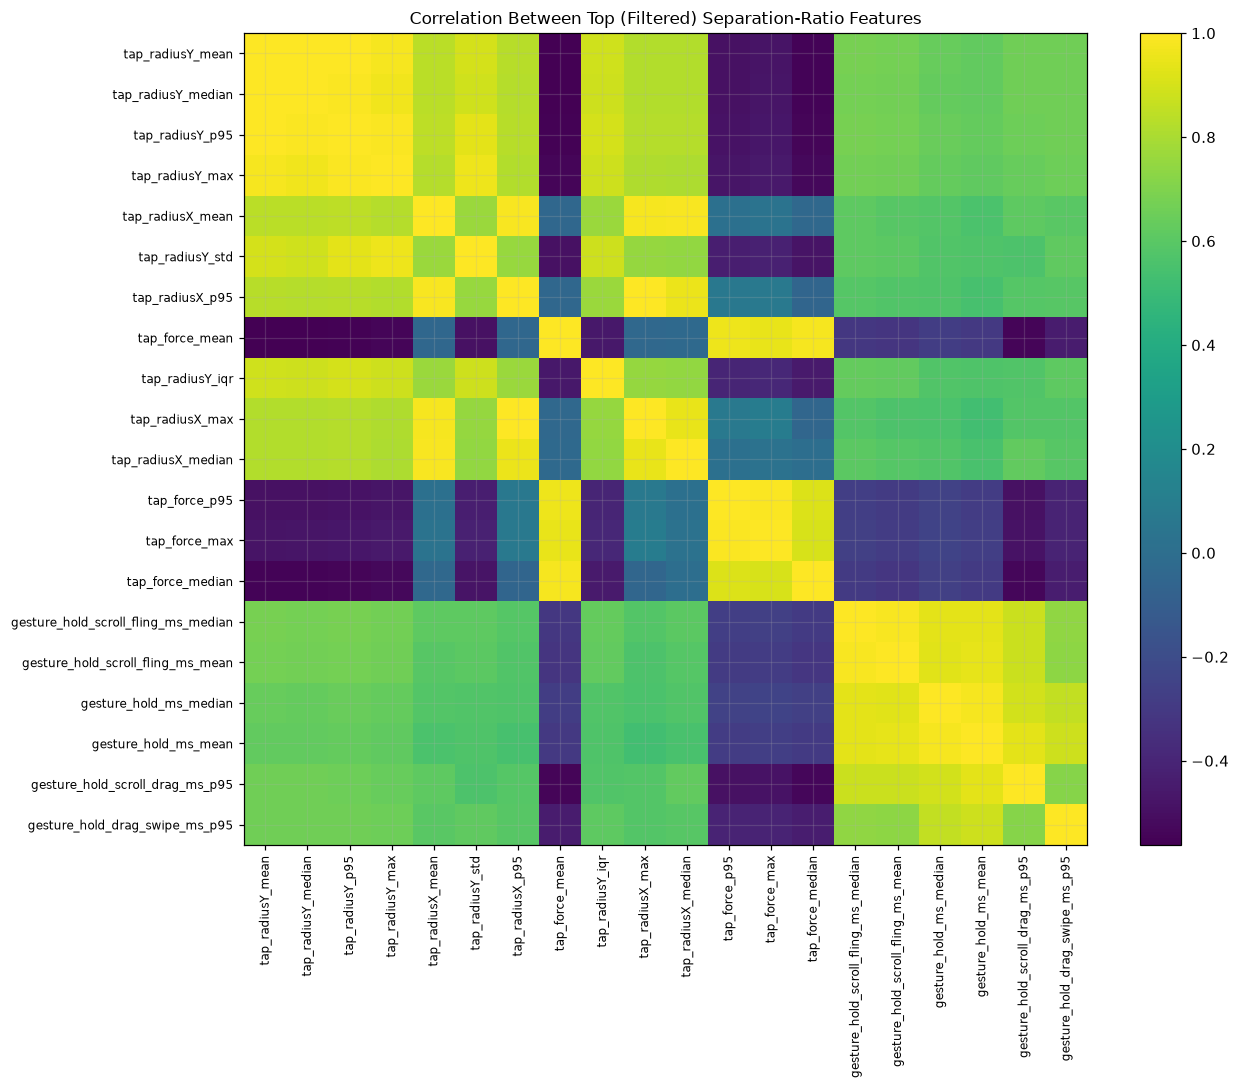

In [45]:
top_features = separation_df.head(20)["feature"].tolist()
corr = df[top_features].corr()

plt.figure(figsize=(12, 10))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90, fontsize=8)
plt.yticks(range(len(corr.index)), corr.index, fontsize=8)
plt.title("Correlation Between Top (Filtered) Separation-Ratio Features")
plt.tight_layout(); plt.show()


In [46]:
tap_cols = feature_families["tap"]
tap_corr = df[tap_cols].corr().abs()
tap_corr_vals = tap_corr.to_numpy(copy=True)
np.fill_diagonal(tap_corr_vals, 0)
tap_corr = pd.DataFrame(tap_corr_vals, index=tap_corr.index, columns=tap_corr.columns)
high_corr_pairs = tap_corr.stack().sort_values(ascending=False)
display(high_corr_pairs.head(30))


tap_y_n            tap_count            1.0
tap_x_n            tap_radiusY_n        1.0
tap_radiusY_n      tap_force_n          1.0
tap_hold_ms_n      tap_y_n              1.0
                   tap_radiusX_n        1.0
                   tap_radiusY_n        1.0
tap_count          tap_y_n              1.0
tap_hold_ms_n      tap_force_n          1.0
tap_coverage       tap_cells_touched    1.0
tap_y_n            tap_force_n          1.0
                   tap_radiusY_n        1.0
                   tap_radiusX_n        1.0
tap_force_n        tap_y_n              1.0
                   tap_x_n              1.0
tap_y_n            tap_x_n              1.0
tap_count          tap_radiusX_n        1.0
tap_y_n            tap_hold_ms_n        1.0
tap_force_n        tap_count            1.0
tap_cells_touched  tap_coverage         1.0
tap_count          tap_force_n          1.0
tap_force_n        tap_hold_ms_n        1.0
tap_x_n            tap_force_n          1.0
                   tap_radiusX_n

In [47]:
# specifically resolve one of the two open judgment calls: is tap_coverage
# redundant with tap_cells_touched?
print("tap_cells_touched vs tap_coverage correlation:",
      df[["tap_cells_touched", "tap_coverage"]].corr().iloc[0, 1])


tap_cells_touched vs tap_coverage correlation: 1.0


## 11. Single-feature deep dive (template)

Parameterize `feature` and re-run this section for any column of interest.

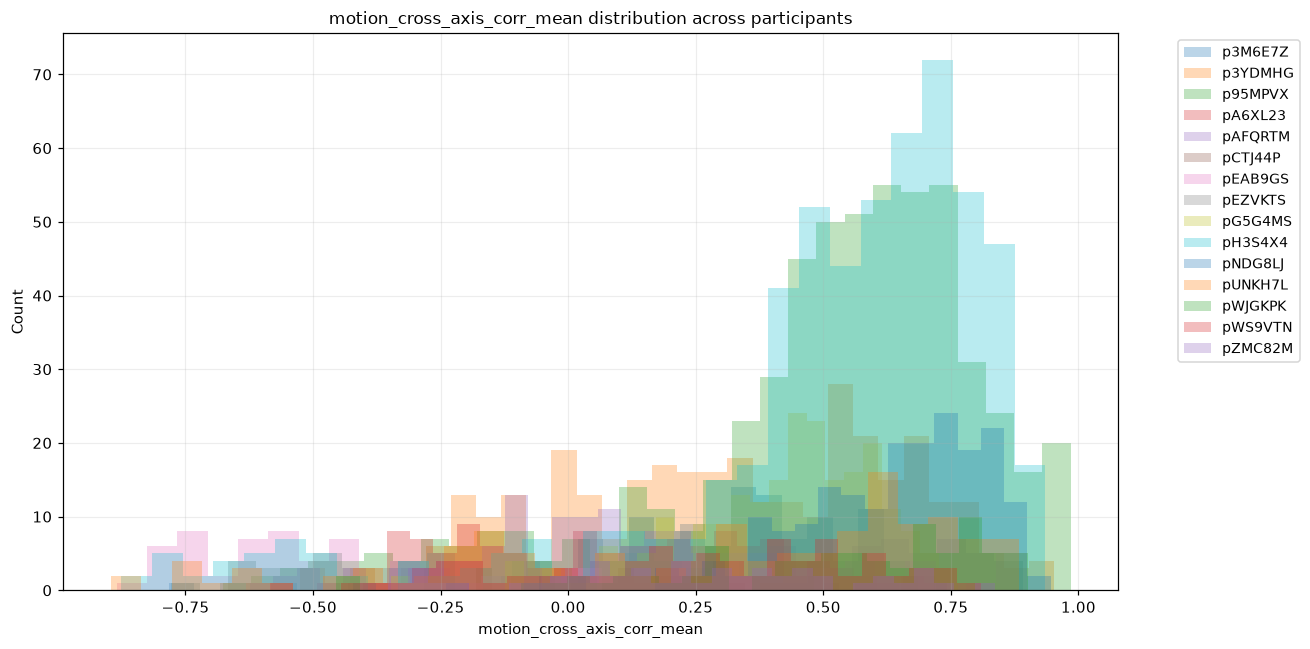

In [48]:
feature = "motion_cross_axis_corr_mean"  # well-populated, not device-locked -- good sanity-check feature

plt.figure(figsize=(12, 6))
for participant, group in df.groupby("participantId"):
    values = group[feature].dropna()
    if len(values) > 0:
        plt.hist(values, bins=30, alpha=0.3, label=participant)
plt.xlabel(feature); plt.ylabel("Count")
plt.title(f"{feature} distribution across participants")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout(); plt.show()


In [49]:
user_feature_means = df.groupby("participantId")[feature].mean().sort_values()
display(user_feature_means)


participantId
pEAB9GS   -0.213205
pAFQRTM    0.054442
pA6XL23    0.080779
pEZVKTS    0.183211
pWS9VTN    0.233962
pZMC82M    0.243387
pUNKH7L    0.268504
p3M6E7Z    0.270059
pCTJ44P    0.303074
p3YDMHG    0.310684
pG5G4MS    0.405298
p95MPVX    0.493347
pH3S4X4    0.501793
pWJGKPK    0.526174
pNDG8LJ    0.622761
pCURDWC         NaN
pG2C8BC         NaN
Name: motion_cross_axis_corr_mean, dtype: float64

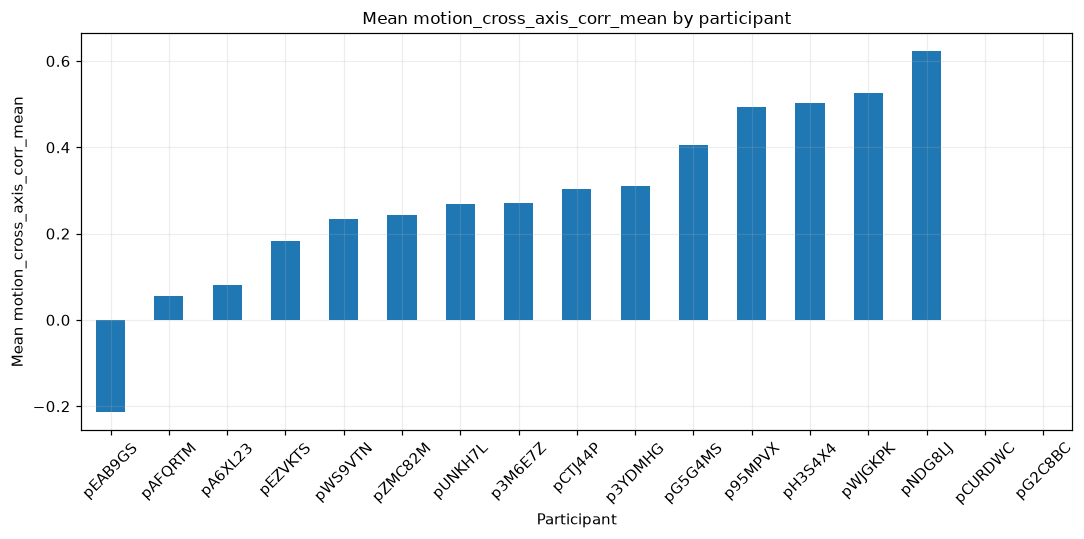

In [50]:
plt.figure(figsize=(10, 5))
user_feature_means.plot(kind="bar")
plt.xlabel("Participant"); plt.ylabel(f"Mean {feature}")
plt.title(f"Mean {feature} by participant")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()


In [51]:
user_stats = df.groupby("participantId")[feature].agg(["mean", "std", "count"])
display(user_stats)


,mean,std,count
participantId,,,
p3M6E7Z,0.270059,0.276310,125
p3YDMHG,0.310684,0.330653,333
p95MPVX,0.493347,0.327718,568
pA6XL23,0.080779,0.290381,122
pAFQRTM,0.054442,0.280915,131
pCTJ44P,0.303074,0.267143,36
pCURDWC,NaN,NaN,0
pEAB9GS,-0.213205,0.557316,78
pEZVKTS,0.183211,0.490590,101


In [52]:
well_supported = user_stats[user_stats["count"] >= MIN_COUNT_PER_PARTICIPANT]
between_user_std = well_supported["mean"].std()
within_user_std = well_supported["std"].mean()
print(f"Participants used: {len(well_supported)} of {len(user_stats)} (>= {MIN_COUNT_PER_PARTICIPANT} windows)")
print("Between-user variation:", between_user_std)
print("Average within-user variation:", within_user_std)
print("Separation ratio:", between_user_std / within_user_std)


Participants used: 15 of 17 (>= 10 windows)
Between-user variation: 0.21320197451338047
Average within-user variation: 0.33312419451535874
Separation ratio: 0.6400074747604403


In [53]:
device_means = df.groupby("deviceModel")[feature].mean()
print("Participant means:"); display(user_feature_means)
print("\nDevice means:"); display(device_means)


Participant means:


participantId
pEAB9GS   -0.213205
pAFQRTM    0.054442
pA6XL23    0.080779
pEZVKTS    0.183211
pWS9VTN    0.233962
pZMC82M    0.243387
pUNKH7L    0.268504
p3M6E7Z    0.270059
pCTJ44P    0.303074
p3YDMHG    0.310684
pG5G4MS    0.405298
p95MPVX    0.493347
pH3S4X4    0.501793
pWJGKPK    0.526174
pNDG8LJ    0.622761
pCURDWC         NaN
pG2C8BC         NaN
Name: motion_cross_axis_corr_mean, dtype: float64


Device means:


deviceModel
google_pixel_standard        0.183211
iphone_13_13_mini            0.533786
iphone_13_pro_pro_max        0.233962
iphone_15                    0.243387
iphone_16                    0.080779
iphone_16_plus               0.334521
iphone_17e                   0.163460
macbook_trackpad                  NaN
older_iphone                 0.384497
windows_laptop_with_mouse         NaN
Name: motion_cross_axis_corr_mean, dtype: float64

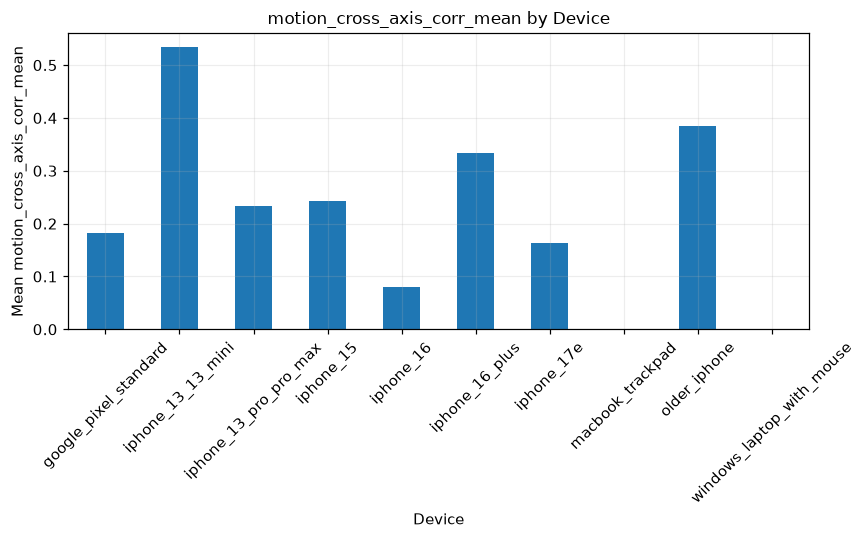

In [54]:
plt.figure(figsize=(8, 5))
device_means.plot(kind="bar")
plt.xlabel("Device"); plt.ylabel(f"Mean {feature}")
plt.title(f"{feature} by Device")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()


In [55]:
user_device_feature = df.groupby(["participantId", "deviceModel"])[feature].agg(["mean", "std", "count"])
display(user_device_feature)


,,mean,std,count
participantId,deviceModel,,,
p3M6E7Z,iphone_16_plus,0.270059,0.276310,125
p3YDMHG,iphone_16_plus,0.310684,0.330653,333
p95MPVX,older_iphone,0.493347,0.327718,568
pA6XL23,iphone_16,0.080779,0.290381,122
pAFQRTM,older_iphone,0.054442,0.280915,131
pCTJ44P,older_iphone,0.303074,0.267143,36
pCURDWC,macbook_trackpad,NaN,NaN,0
pEAB9GS,iphone_17e,-0.213205,0.557316,78
pEZVKTS,google_pixel_standard,0.183211,0.490590,101


## 12. PCA sanity check

In [56]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = df[FEATURE_COLS].copy()
X = X.dropna(axis=1, how="all")
print(f"{X.shape[1]} of {len(FEATURE_COLS)} behavioural features retained (dropped fully-empty)")

X_imputed = SimpleImputer(strategy="median").fit_transform(X)
X_scaled = StandardScaler().fit_transform(X_imputed)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


555 of 577 behavioural features retained (dropped fully-empty)


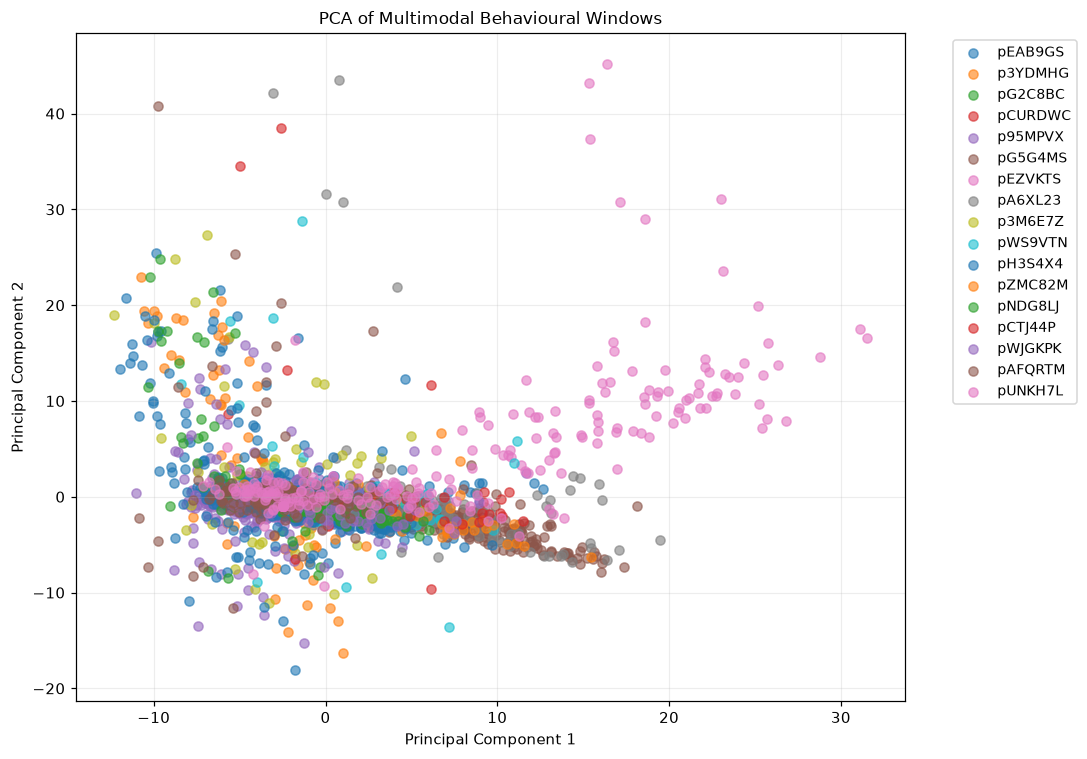

Explained variance: [0.0605548  0.04384419]


In [57]:
plt.figure(figsize=(10, 7))
for participant in df["participantId"].unique():
    mask = df["participantId"] == participant
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], alpha=0.6, label=participant)
plt.xlabel("Principal Component 1"); plt.ylabel("Principal Component 2")
plt.title("PCA of Multimodal Behavioural Windows")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout(); plt.show()

print("Explained variance:", pca.explained_variance_ratio_)


## Open questions

- `tap_radiusX`/`tap_radiusY`/`tap_force` look like a `deviceModel` artifact
  (Section 9) rather than behaviour on iOS -- worth checking whether this also
  taints `coupling_tap_accel_*` or anything else downstream that consumes
  tap geometry, and deciding whether to exclude these three families or
  restrict them to Android-only analysis.
- `tap_coverage`/`tap_cells_touched` correlation (Section 10) settles one open
  judgment call -- they move together, so whatever's decided for one should
  apply to the other.
- The filtered separation-ratio metric (Section 8) is still a simple std-ratio,
  not a formal ICC -- fine for a first ranking pass, but worth moving to a
  proper ICC(1) (one-way ANOVA between/within variance decomposition) before
  this feeds any actual feature-selection decision, since std-ratio isn't
  variance-additive the way ICC is.
- Coupling (198 columns, the largest family) hasn't had its own missingness/
  separation deep-dive yet -- only skimmed via the family-level aggregates
  here.
